# Introduction
The goal of this project is to perform **face detection** by locating the **eye area** using the **Integral Image technique**.

We will:
1. Compute the Integral Image of a given face image.
2. Use it to calculate local pixel sums efficiently.
3. Convolve a kernel to detect the eye area.
4. Extract and display the detected eye region.

This notebook includes four main functions:
- `CalculateIntegral()`
- `CalculateLocalSum()`
- `DetectEye()`
- `ExtractDetectedEye()`

### Load the Image

Convert image to grayscale (since we only need intensity)



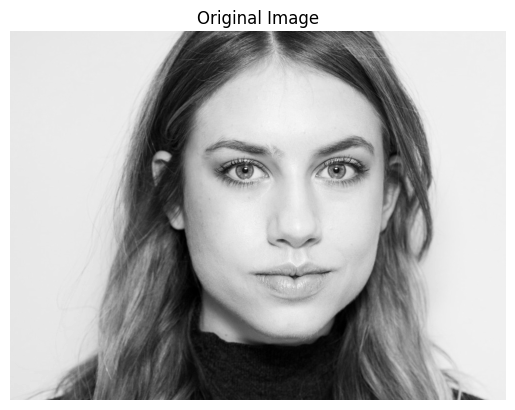

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load grayscale image
image_path = '/kaggle/input/images/Image 1.jpeg'  
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) ## convert to array

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

### CalculateIntegral

**Input:**  
- 2D array representing the image

**Output:**  
- 2D array representing the integral image

**Description:**  
For each pixel (x, y):
`ii(x, y) = image(x, y) + ii(x-1, y) + ii(x, y-1) - ii(x-1, y-1)`

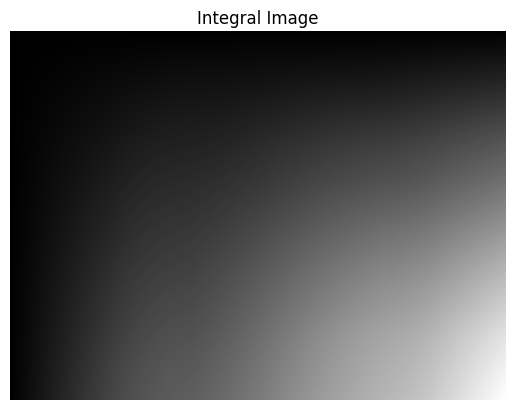

In [2]:
def CalculateIntegral(image):
    h, w = image.shape
    ii = np.zeros((h, w), dtype=np.float64)

    for y in range(h):
        for x in range(w):
            ii[y, x] = image[y, x]
            if x > 0:
                ii[y, x] += ii[y, x-1]
            if y > 0:
                ii[y, x] += ii[y-1, x]
            if x > 0 and y > 0:
                ii[y, x] -= ii[y-1, x-1]
    return ii

# Test it
integral_img = CalculateIntegral(image)
plt.imshow(integral_img, cmap='gray')
plt.title('Integral Image')
plt.axis('off')
plt.show()

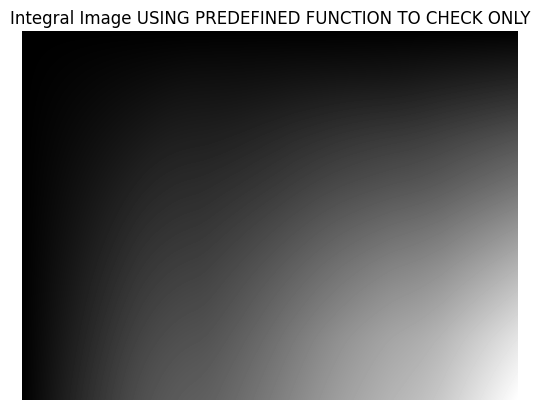

In [4]:
import cv2
integral_cv = cv2.integral(image)
integral_vis = integral_cv[1:, 1:]

plt.imshow(integral_vis, cmap='gray')
plt.title('Integral Image USING PREDEFINED FUNCTION TO CHECK ONLY')
plt.axis('off')
plt.show()


### CalculateLocalSum

**Input:**  
- An integral image (2D array)
- Two pairs of coordinates: (x0, y0) (upper left), (x1, y1) (lower right)

**Output:**  
- The local sum for the rectangular area defined by the pair of points

**Description:**  
This function calculates the local sum for any rectangular area using the integral image. It should not contain any loops.

In [5]:
def CalculateLocalSum(ii, p0, p1):
    x0, y0 = p0
    x1, y1 = p1

    total = ii[y1, x1]
    if x0 > 0:
        total -= ii[y1, x0 - 1]
    if y0 > 0:
        total -= ii[y0 - 1, x1]
    if x0 > 0 and y0 > 0:
        total += ii[y0 - 1, x0 - 1]
    return total

# Example test
sum_test = CalculateLocalSum(integral_img, (10,10), (50,50))
print(sum_test)

387388.0


In [6]:
np.sum(image[10:51, 10:51])
#yes

387388

### Define the Kernel (Eye Detector)

The kernel is made of several rectangles, each with a specific weight.

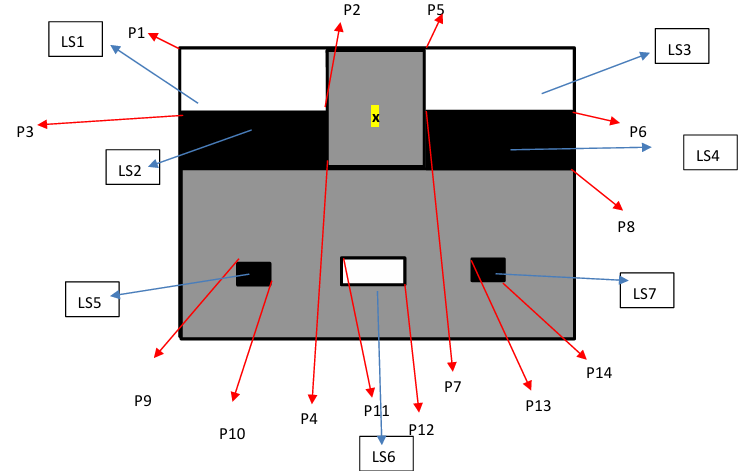
| Rectangle | Relative Position           | Weight | Color  |
|-----------|-----------------------------|--------|--------|
| LS1       | Upper-left                  | +1     | White  |
| LS2       | Upper-middle (between eyes) | –1     | Black  |
| LS3       | Upper-right                 | +1     | White  |
| LS4       | Lower-left                  | –1     | Black  |
| LS5       | Lower-middle                | –1     | Black  |
| LS6       | Lower-center (between eyes) | +2     | White  |
| LS7       | Lower-right                 | –1     | Black  |


*Assign regions and boundaries based on P1–P14 as shown in the assignment image. 
Weights strictly follow the assignment instructions for color: white = +1, black = –1, gray = 0 (neglected).*

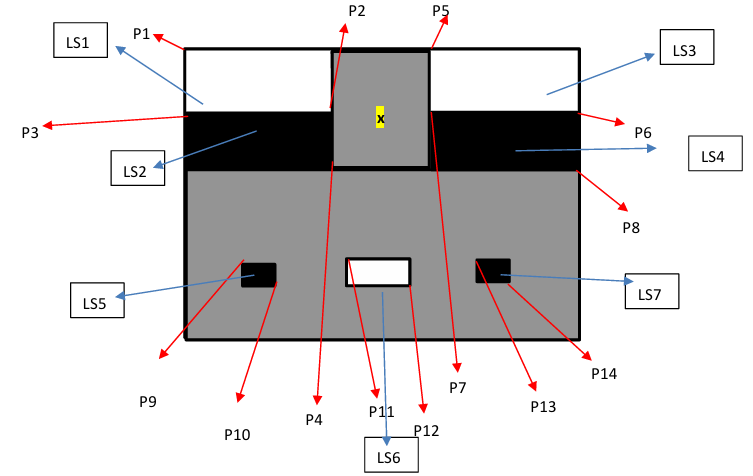
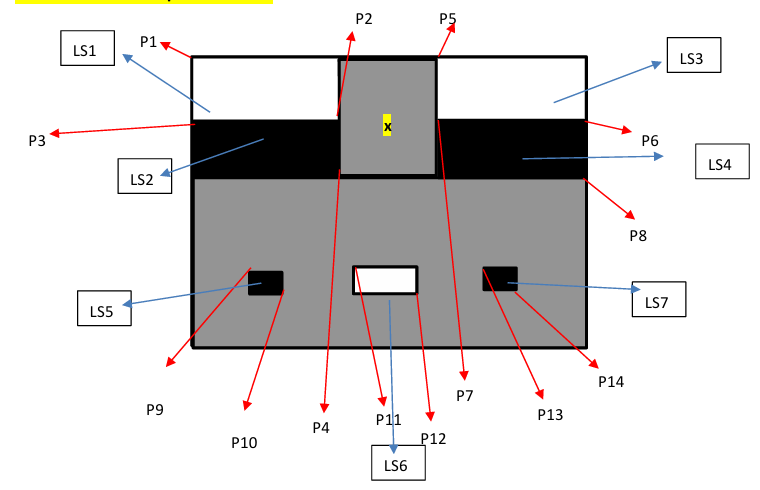
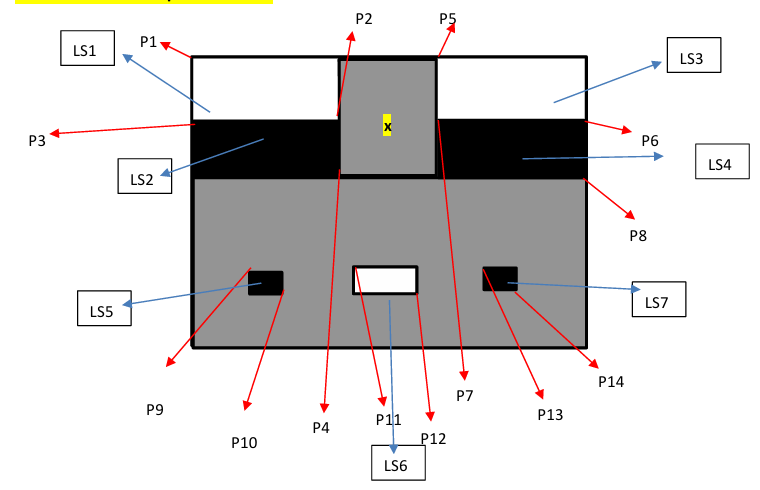
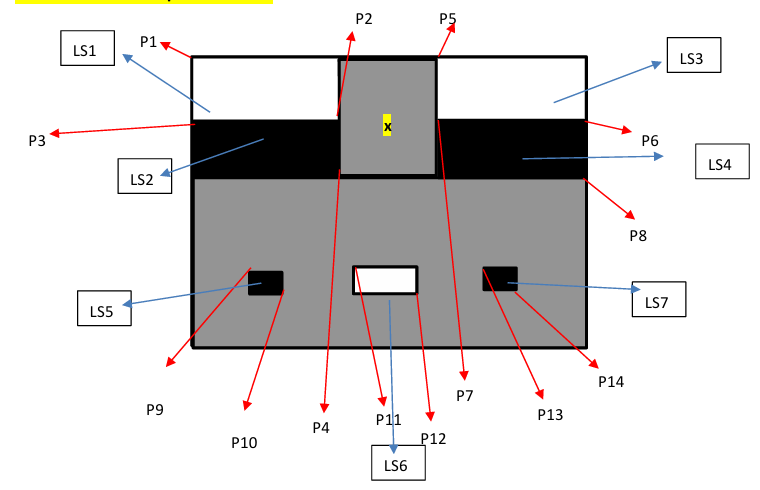
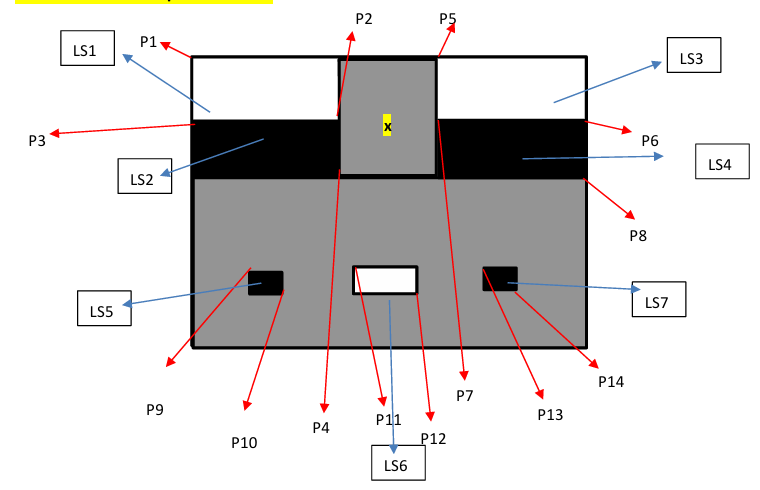
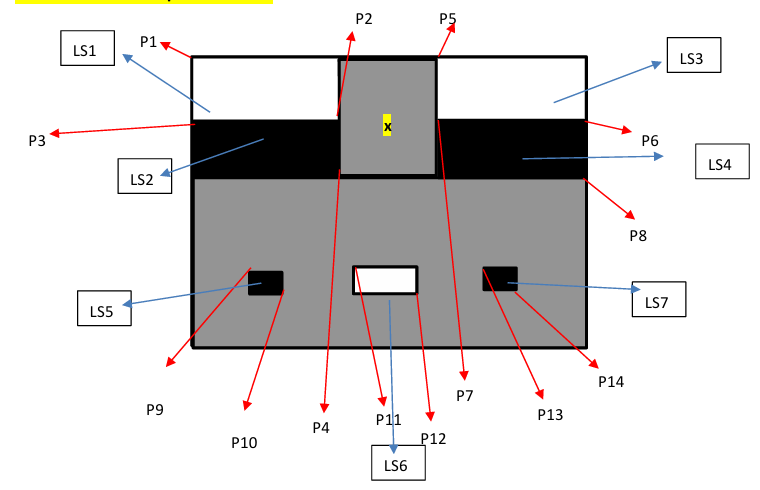

### Slide the kernel over the image. For each position:

- Compute local sums for each rectangle using the integral image.
- Multiply each by its weight.
- Add them to get total response.
- Store result`.

### DetectEye

**Input:**  
- The integral image (2D array)
- Kernel width (n)

**Output:**  
- Coordinates (i, j) representing the position of the maximum score from kernel convolution

**Description:**  
Finds the region with the highest score corresponding to the eye area, by convolving the kernel across the face image. Kernel height is calculated as m = 0.15n. The kernel should use the structure provided in the assignment.

### ExtractDetectedEye

**Input:**  
- The original image (2D array)
- Position of detected maximum score (i, j)
- Kernel width (n)

**Output:**  
- A 2D array representing the image area containing the detected eye region

**Description:**  
Draws around the detected maximum position using the kernel size, retrieves and returns the pixel region corresponding to the eyes.